# Find P(S|chord)

In [156]:
import midi_parser as mp
import numpy as np
import importlib
import matplotlib.pyplot as plt

importlib.reload(mp)
# import pathlib as pl
# import os
# import matplotlib.pyplot as plt
# import glob

<module 'midi_parser' from 'c:\\Users\\madel\\OneDrive\\Documents\\School\\dsp\\SATB-Harmonization\\midi_parser.py'>

In [26]:
chord_to_idx = mp.getRootToIdxDict()

In [99]:
import glob
indir = "insert_path_here"
dir = f"{indir}/*"
filepaths = glob.glob(dir)

In [150]:
# metadata has form [tempo, PPQ, length_ticks, (numerator, denominator)]
midi_path='mix'
([S, A, T, B], _metadata) = mp.unpack_midi(midi_path) # get piano rolls for S, A, T, and B parts
roll = S + A + T + B # get combined piano roll
chord_roll, S = mp.get_chord_roll_and_S(midi_path)
print(np.shape(chord_roll))
print(np.shape(S))


(21, 128)
(128, 128)


In [ ]:

# get chord roll [chord by durSamps]
# get piano roll for soprano line
# chord by soprano line matrix and count up

def getChordToS(midi_filename):
# TODO: adjust for multiple files within the path
# TODO: update for 3 dimensions
    """
    Construct pdf for soprano line given chord
    Inputs:
        - midi_filename: file specifying midi of interest
    Outputs:
        - chord_to_s: a (numNotes) x (numChords) matrix, each entry specifying P(S|C)
    """
    # C = chord roll
    # S = soprano line piano roll
    C, S = mp.get_chord_roll_and_S(midi_filename)
    sampDur = len(C[0])
    numChords = len(C)
    numNotes = len(S[0])
    chord_to_s = np.zeros((numNotes, numChords), dtype=float)
    for samp in range(sampDur):
        samp_notes = S[:,samp]
        samp_chords = C[:, samp]
        chord_to_s = np.add(chord_to_s, np.outer(samp_notes, samp_chords), dtype=float)
        
    norm = np.sum(chord_to_s, axis=0)
    # norm_mat = np.transpose(np.matlib.repmat(norm,len(chord_to_s[0]),1))
    norm_mat = 0.000001*np.ones(np.shape(chord_to_s))
    norm_mat = np.add(norm_mat, (np.matlib.repmat(norm, len(chord_to_s), 1)))
    chord_to_s = chord_to_s/norm_mat
    # print(np.sum(chord_to_s, axis=0)) # each chord (of 21 options) adds up to probability 1 or 0
    return chord_to_s

[0.99999975 0.99999967 0.99999993 0.         0.99999967 0.
 0.         0.99999967 0.9999998  0.99999983 0.9999995  0.99999986
 0.         0.         0.         0.         0.         0.
 0.         0.         0.        ]


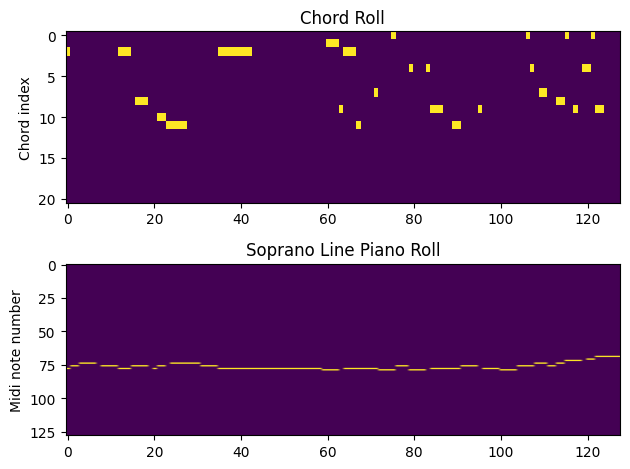

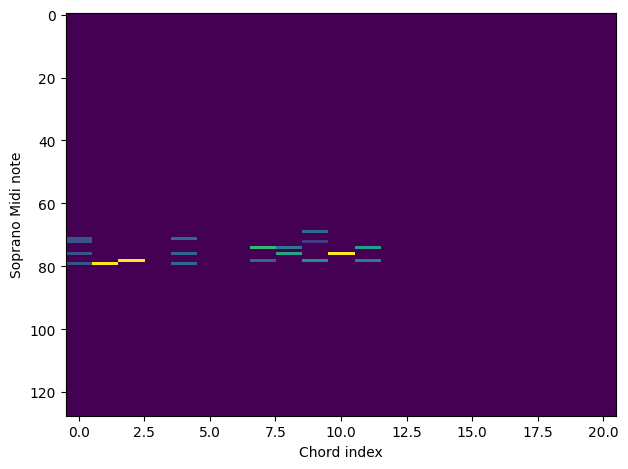

In [245]:
chord_to_s = getChordToS('mix')

plt.figure(1)
plt.subplot(211)
plt.title("Chord Roll")
plt.ylabel("Chord index")
plt.imshow(chord_roll, aspect='auto')
plt.subplot(212)
plt.title("Soprano Line Piano Roll")
plt.ylabel("Midi note number")
plt.imshow(S, aspect='auto')
plt.tight_layout()
plt.figure(2)
# plt.subplot(313)
plt.ylabel("Soprano Midi note")
plt.xlabel("Chord index")
plt.imshow(chord_to_s, aspect='auto')
plt.tight_layout()
